In [4]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mlflow dagshub xgboost imbalanced-learn scikit-learn -q

!git clone https://github.com/Dimuthu21/fraud-risk-platform.git
import sys
sys.path.append('/content/fraud-risk-platform')

from src.features import save_train_columns

Mounted at /content/drive
fatal: destination path 'fraud-risk-platform' already exists and is not an empty directory.


Connect MLflow to DagsHub

In [2]:
import dagshub
dagshub.init(repo_owner='Dimuthu21', repo_name='fraud-risk-platform', mlflow=True)
import mlflow

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0a5d9daf-6faf-4a1b-86e8-5b558bdf4cb8&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f11267ab350dfadc14ed140dd9b41651966429eb99b78837e8dd822878e02832




Accessing as Dimuthu21

Initialized MLflow to track repo "Dimuthu21/fraud-risk-platform"

Repository Dimuthu21/fraud-risk-platform initialized!

Load processed splits + save the training column schema

In [5]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/test.csv')

save_train_columns(train_df)  # writes models/train_columns.json — locked in now for the API later

Split features/target

In [6]:
target_col = 'fraud_bool'
feature_cols = [c for c in train_df.columns if c != target_col]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

Evaluation helper (PR-AUC, not accuracy, is your headline metric)

In [7]:
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score, recall_score, precision_score

def evaluate(model, X, y, threshold=0.5):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y, probs),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
    }

Baseline: Logistic Regression, no imbalance handling

In [8]:
from sklearn.linear_model import LogisticRegression

# quick one-off imputation of -1 sentinels, just for this baseline (see reasoning above)
X_train_lr = X_train.copy()
X_val_lr = X_val.copy()
sentinel_cols = ['prev_address_months_count', 'bank_months_count', 'current_address_months_count',
                  'session_length_in_minutes', 'device_distinct_emails_8w']
for col in sentinel_cols:
    median_val = X_train_lr.loc[X_train_lr[col] != -1, col].median()
    X_train_lr[col] = X_train_lr[col].replace(-1, median_val)
    X_val_lr[col] = X_val_lr[col].replace(-1, median_val)

with mlflow.start_run(run_name="logreg_baseline_no_weighting"):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_lr, y_train)
    metrics = evaluate(model, X_val_lr, y_val)
    mlflow.log_params({"model": "LogisticRegression", "class_weight": "none"})
    mlflow.log_metrics(metrics)
    print(metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'pr_auc': np.float64(0.05665587711423252), 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
🏃 View run logreg_baseline_no_weighting at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0/runs/b0c0760752334cfd9c5e42248af9f435
🧪 View experiment at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0


Logistic Regression with class weighting

In [9]:
with mlflow.start_run(run_name="logreg_balanced"):
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train_lr, y_train)
    metrics = evaluate(model, X_val_lr, y_val)
    mlflow.log_params({"model": "LogisticRegression", "class_weight": "balanced"})
    mlflow.log_metrics(metrics)
    print(metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'pr_auc': np.float64(0.06078348026083579), 'precision': 0.02742390619435084, 'recall': 0.6903448275862069, 'f1': 0.052752233142736686}
🏃 View run logreg_balanced at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0/runs/fb88581cf11b4edabc79d3c950dce17d
🧪 View experiment at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0


Random Forest, class-weighted

In [10]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest_balanced"):
    model = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    metrics = evaluate(model, X_val, y_val)
    mlflow.log_params({"model": "RandomForest", "n_estimators": 200, "class_weight": "balanced"})
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model, "model")
    print(metrics)

2026/08/13 10:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'pr_auc': np.float64(0.11635125736830407), 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
🏃 View run random_forest_balanced at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0/runs/5e6576016b414a6085f03a24beba6a0c
🧪 View experiment at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0


XGBoost

In [11]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

with mlflow.start_run(run_name="xgboost_scaled"):
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric='aucpr', n_jobs=-1, random_state=42
    )
    model.fit(X_train, y_train)
    metrics = evaluate(model, X_val, y_val)
    mlflow.log_params({"model": "XGBoost", "n_estimators": 300, "max_depth": 6, "scale_pos_weight": round(scale_pos_weight,2)})
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(model, "model")
    print(metrics)

scale_pos_weight: 96.53269537480064


2026/08/13 10:19:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'pr_auc': np.float64(0.15886406816713305), 'precision': 0.06685166498486378, 'recall': 0.7310344827586207, 'f1': 0.1225008667514157}
🏃 View run xgboost_scaled at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0/runs/71ef732d9a3b404588e1fbef57bd6600
🧪 View experiment at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0


In [12]:
import os
os.makedirs('/content/fraud-risk-platform/models', exist_ok=True)

In [5]:
import sys, importlib

# Check for a naming collision
print("'src' already in sys.modules?", 'src' in sys.modules)

# Confirm the file really exists at the path Python would look for
import os
print(os.path.exists('/content/fraud-risk-platform/src/features.py'))
print(os.path.exists('/content/fraud-risk-platform/src/__init__.py'))

'src' already in sys.modules? False
True
False


In [6]:
import sys
sys.path.insert(0, '/content/fraud-risk-platform/src')

import features
from features import save_train_columns, load_train_columns

print("Import successful")

Import successful


In [7]:
# 4. Reconnect MLflow to DagsHub (will ask you to click a link + authorize again)
import dagshub
dagshub.init(repo_owner='Dimuthu21', repo_name='fraud-risk-platform', mlflow=True)
import mlflow

# 5. Reload your processed data
import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/fraud-risk-platform/processed/test.csv')

target_col = 'fraud_bool'
feature_cols = [c for c in train_df.columns if c != target_col]
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

# 6. Redefine the evaluate() helper
from sklearn.metrics import average_precision_score, f1_score, recall_score, precision_score

def evaluate(model, X, y, threshold=0.5):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y, probs),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
    }

print("Reconnected. Shapes:", X_train.shape, X_val.shape)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c8af293a-6870-4879-bc48-5861d6e65f12&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=52a8a51b7bd19a9ee7aabcac612cbb049d7dfe8f3bffa513e3bd2c408acdab7e




Accessing as Dimuthu21

Initialized MLflow to track repo "Dimuthu21/fraud-risk-platform"

Repository Dimuthu21/fraud-risk-platform initialized!

Reconnected. Shapes: (794989, 54) (108168, 54)


 Threshold tuning + Optuna + SHAP

Step 1 — Retrain  XGBoost winner (so it's back in memory) and find the real optimal threshold

In [8]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import precision_recall_curve

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr', n_jobs=-1, random_state=42
)
model.fit(X_train, y_train)

val_probs = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

# Find the threshold that maximizes F1
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"At that threshold — Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")

Best threshold: 0.8891
At that threshold — Precision: 0.1892, Recall: 0.3186, F1: 0.2374


 Optuna tuning on XGBoost

In [9]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'n_jobs': -1,
        'random_state': 42,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_train, y_train)
    probs = m.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, probs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)   # 25 trials keeps this to a reasonable runtime on Colab

print("Best PR-AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-08-13 11:35:04,642] A new study created in memory with name: no-name-c509a484-acce-4534-9ccc-c489c4ed0b86
[I 2026-08-13 11:36:27,992] Trial 0 finished with value: 0.15543267020862242 and parameters: {'n_estimators': 318, 'max_depth': 9, 'learning_rate': 0.032958208055670325, 'subsample': 0.7901177359033942, 'colsample_bytree': 0.8928750730982626, 'min_child_weight': 6}. Best is trial 0 with value: 0.15543267020862242.
[I 2026-08-13 11:37:28,539] Trial 1 finished with value: 0.15996260751354027 and parameters: {'n_estimators': 318, 'max_depth': 8, 'learning_rate': 0.05977768254538056, 'subsample': 0.7048912925910984, 'colsample_bytree': 0.9918017511958567, 'min_child_weight': 8}. Best is trial 1 with value: 0.15996260751354027.
[I 2026-08-13 11:38:14,343] Trial 2 finished with value: 0.16082686630527102 and parameters: {'n_estimators': 293, 'max_depth': 5, 'learning_rate': 0.013795741115462709, 'subsample': 0.6066559868860627, 'colsample_bytree': 0.9957671913537585, 'min_child_w

Best PR-AUC: 0.18548353289185326
Best params: {'n_estimators': 397, 'max_depth': 3, 'learning_rate': 0.07993347737927162, 'subsample': 0.9039924989273324, 'colsample_bytree': 0.7560744739330062, 'min_child_weight': 1}


Train the final model with best params, find its threshold, log everything to MLflow

In [10]:
best_params = study.best_params
best_params.update({'scale_pos_weight': scale_pos_weight, 'eval_metric': 'aucpr', 'n_jobs': -1, 'random_state': 42})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

val_probs = final_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
final_threshold = float(thresholds[best_idx])

final_metrics = evaluate(final_model, X_val, y_val, threshold=final_threshold)

with mlflow.start_run(run_name="xgboost_optuna_tuned_final"):
    mlflow.log_params(best_params)
    mlflow.log_param("decision_threshold", final_threshold)
    mlflow.log_metrics(final_metrics)
    mlflow.xgboost.log_model(final_model, "model")
    print(final_metrics)

2026/08/13 11:56:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'pr_auc': np.float64(0.18548353289185326), 'precision': 0.19932177844762622, 'recall': 0.36482758620689654, 'f1': 0.2577972709551657}
🏃 View run xgboost_optuna_tuned_final at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0/runs/8c99bdaa45b74eaa90c989a0eb380783
🧪 View experiment at: https://dagshub.com/Dimuthu21/fraud-risk-platform.mlflow/#/experiments/0


SHAP explainability

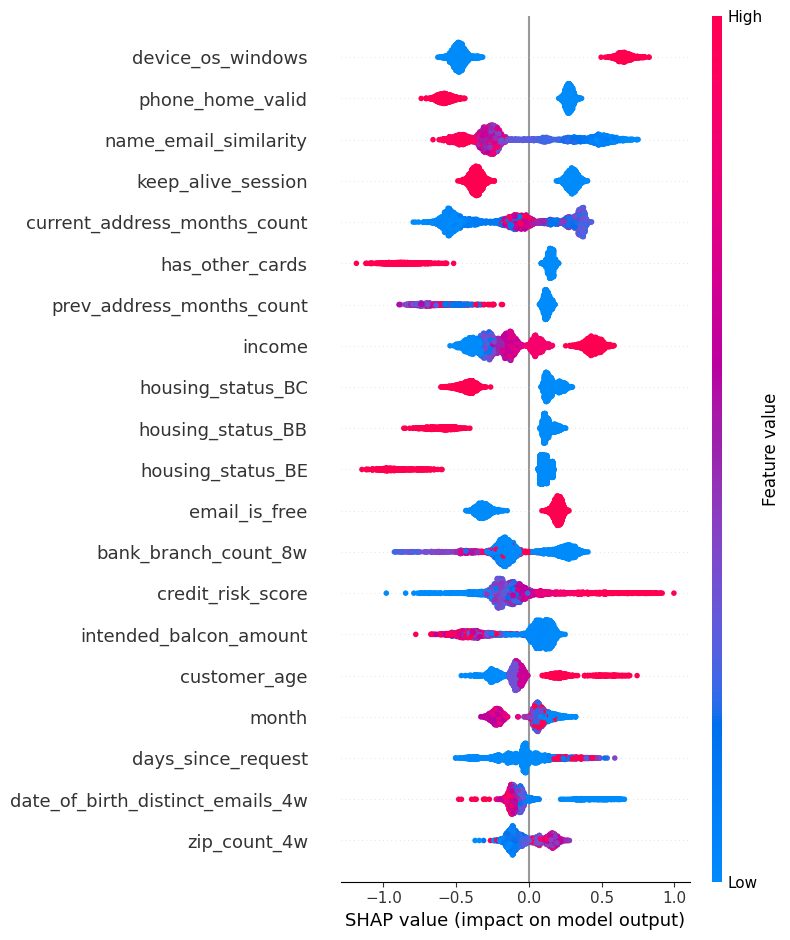

In [11]:
import shap

sample = X_train.sample(3000, random_state=42)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(sample)

# Global summary plot
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud-risk-platform/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

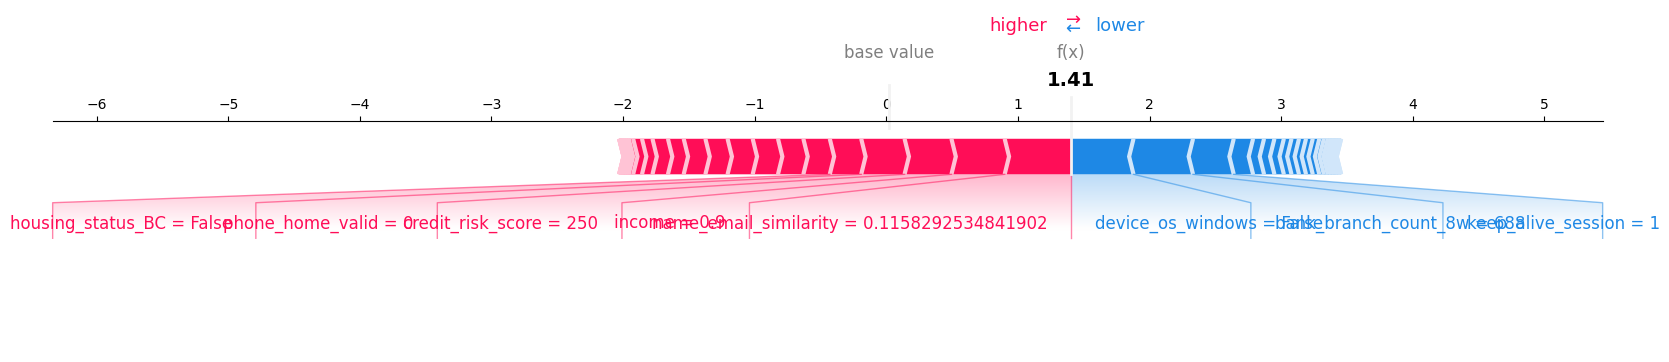

In [12]:
fraud_idx = y_val[y_val == 1].index[0]
single_case = X_val.loc[[fraud_idx]]

shap_single = explainer.shap_values(single_case)
shap.force_plot(explainer.expected_value, shap_single, single_case, matplotlib=True, show=False)
plt.savefig('/content/drive/MyDrive/fraud-risk-platform/shap_single_case.png', dpi=150, bbox_inches='tight')
plt.show()

Save the final model + threshold for the API to use later

In [13]:
import joblib, json, os

os.makedirs('/content/fraud-risk-platform/models', exist_ok=True)
joblib.dump(final_model, '/content/fraud-risk-platform/models/fraud_model.pkl')

with open('/content/fraud-risk-platform/models/model_config.json', 'w') as f:
    json.dump({"decision_threshold": final_threshold, "best_params": best_params}, f, indent=2)